In [512]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [513]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [514]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [515]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='drucker_pager.tcl',
                output_file='drucker_pager.tcl.py',
                prefix="ops")

In [516]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (116878422819)>


In [517]:
ops.wipe()
ops.model('BasicBuilder', '-ndm', 2, '-ndf', 3)
#model nodes
x1 = 0.0
y1 = 0.0
x2 = 1.0
y2 = 0.0
x3 = 1.0
y3 = 1.0
x4 = 0.0
y4 = 1.0

#create nodes

ops.node(1, x1, y1)
ops.node(2, x2, y2)
ops.node(3, x3, y3)
ops.node(4, x4, y4)

#boundary conditions
ops.fix(1, 1, 1, 1)
ops.fix(2, 1, 1, 1)
ops.fix(3, 0, 0, 1)
ops.fix(4, 0, 0, 1)
ops.equalDOF(3,4,1,2) #make node 3 and 4 equal displacement at degrees 1 & 2

ops.nDMaterial('DruckerPrager', 2, 27777.78, 9259.26, 5.0, 0.398, 0.398, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.7) # 9259.26
ops.element('SSPquadUP',1, 1,2,3,4, 2, 1.0, 2.2e6, 1.0, 0, 0, 0, 1.0e-5)

print('model Built...')

model Built...


In [518]:
ops.recorder('Node', '-file', '2ddisplacements1.out', '-time', '-dT', 0.1, '-nodeRange', 1, 8, '-dof', 1, 2, 3, 'disp')
ops.recorder('Element', '-ele', 1, '-time', '-file', '2dstress1.out', '-dT', 0.1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', '2dstrain1.out', '-dT', 0.1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', '2dstate1.out', '-dT', 0.1, 'state')

181

In [519]:
ops.recorder('Element','-file', '2adstress1.txt','-time','-dT', 0.1,'-ele', 1, 'stress')
ops.recorder('Element','-file', '2dstrain1.txt','-time','-dT', 0.1,'-ele', 1, 'strain')

183

In [520]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [521]:
pN = 5.0

In [522]:
ops.recorder('Node', '-file', '2ddisplacements1.out', '-time', '-dT', 0.1, '-nodeRange', 1, 8, '-dof', 1, 2, 3, 'disp')
ops.recorder('Element', '-ele', 1, '-time', '-file', '2dstress1.out', '-dT', 0.1, 'material', 2, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', '2dstrain1.out', '-dT', 0.1, 'material', 2, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', '2dstate1.out', '-dT', 0.1, 'material', 2, 'state')

187

In [523]:
ops.timeSeries('Path', 1, '-time', 0, 10,100, '-values', 0, 1, 1, '-factor', 1)
ops.pattern('Plain', 1, 1)
ops.load(1, pN, 0.0, 0.0)
ops.load(4, pN, 0.0, 0.0)
ops.load(2, -pN, 0.0, 0.0)
ops.load(3, -pN, 0.0, 0.0)

In [524]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [525]:
ops.timeSeries('Path', 2, '-time', 0, 10, 100, '-values', 0, 1, 5, '-factor', 1)
ops.pattern('Plain', 2, 2)
ops.load(1, pN, 0.0, 0.0)
ops.load(4, pN, 0.0, 0.0)
ops.load(2, -pN, 0.0, 0.0)
ops.load(3, -pN, 0.0, 0.0)
ops.load(3, 0.0, -pN, 0.0)
ops.load(4, 0.0, -pN, 0.0)

In [526]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [527]:
ops.integrator('LoadControl', 0.1)
ops.numberer('RCM',)
ops.system('SparseGeneral',)
ops.constraints('Transformation',)
ops.test('NormDispIncr', 1e-05, 10, 1)
ops.algorithm('Newton',)
ops.analysis('Static',)
print('starting the hydrostatic analysis...')

starting the hydrostatic analysis...


In [528]:
ODB = opst.post.CreateODB(
    odb_tag="dracker_prager_2d",
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
for _ in range(1000):
    ops.analyze(1,)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 1.11022e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 1.11022e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.49231e-06 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 2.492

OPSTOOL ::  All responses data with _odb_tag = dracker_prager_2d saved in 
.opstool.output/RespStepData-dracker_prager_2d.nc!

In [529]:
node_resp = opst.post.get_nodal_responses(odb_tag="dracker_prager_2d")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-dracker_prager_2d.nc ...

<xarray.Dataset> Size: 597kB
Dimensions:             (time: 1001, nodeTags: 4, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.1 0.2 0.3 ... 99.8 99.9 100.0
  * nodeTags            (nodeTags) int64 32B 1 2 3 4
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    vel                 (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    accel               (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    reaction            (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 16kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Displacement i

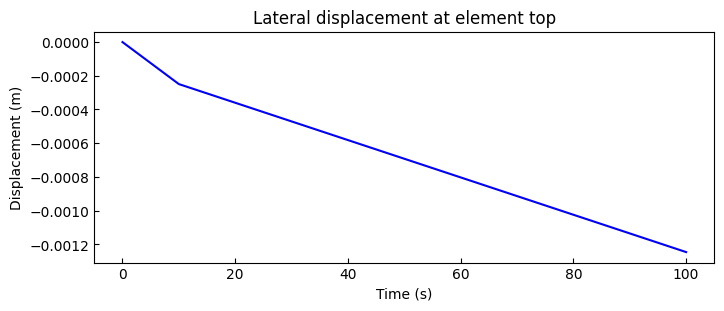

In [530]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UY")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UY")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 - disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

In [531]:
ele_resp = opst.post.get_element_responses(odb_tag="dracker_prager_2d", ele_type="Plane")

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-dracker_prager_2d.nc ...

In [532]:
print("Data Variables in Element Responses:", ele_resp.data_vars)

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 12kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 12kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 48kB 0.0 ... 0.0
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 48kB 0.0 ... 0.0
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 48kB 0.0 ... 0.0
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 48kB 0.0 ... 0.0
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 16kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 16kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 64kB 0.0 ... 0.0
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 64kB 0.0 ... 0.0


In [537]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1).values # tr(σ)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1).values # s+q kin, where s is the deviatoric stress tensor and q kin is the back-stress tensor
#sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1) # tr(εp)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1).values 
#eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)
print(sigma11)

[[  0.        ]
 [ -0.05384615]
 [ -0.10769231]
 ...
 [-26.875214  ]
 [-26.899145  ]
 [-26.923077  ]]


In [534]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

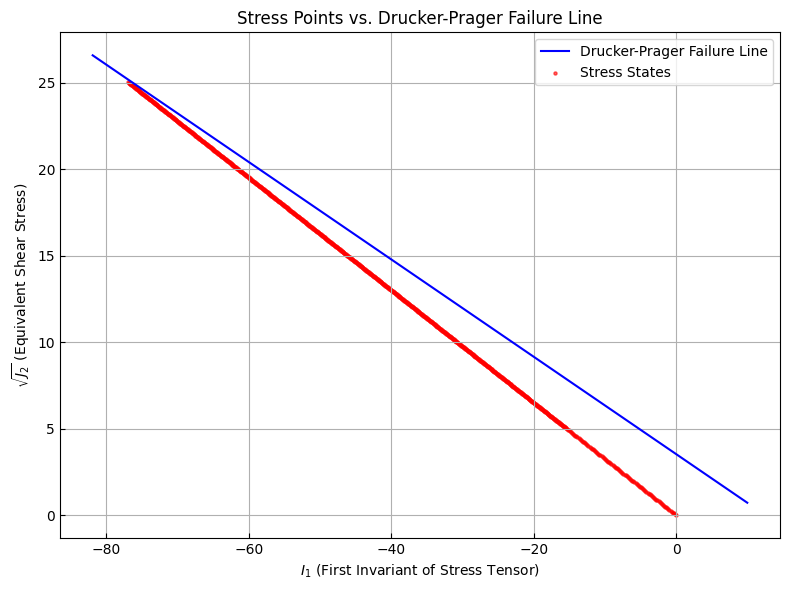

In [535]:
# drucker_prager_with_xarray.py

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract arrays from xarray (shape: [time, GaussPoints])
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1).values  # shape: (1001, 8)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1).values
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1).values

# Step 2: Compute I1 = σ11 + σ22 + σ33
I1_vals = sigma11 + sigma22 + sigma33  # First invariant of the stress tensor

# Step 3: Compute deviatoric stress s = σ - (1/3) I1
mean_stress = I1_vals / 3
s11 = sigma11 - mean_stress
s22 = sigma22 - mean_stress
s33 = sigma33 - mean_stress

# Step 4: Compute sqrt(J2) = sqrt(0.5 * (s11² + s22² + s33²))
J2_vals = 0.5 * (s11**2 + s22**2 + s33**2)
sqrt_J2_vals = np.sqrt(J2_vals)

# Step 5: Flatten for scatter plotting
I1_flat = I1_vals.flatten()
sqrt_J2_flat = sqrt_J2_vals.flatten()

# Step 6: Drucker-Prager failure line
rho = 0.398
sigma_Y = 5
I1_line = np.linspace(np.min(I1_flat)-5, np.max(I1_flat)+10, 500)
dp_line = - (1 / np.sqrt(2)) * rho * I1_line + (1 / np.sqrt(2)) * sigma_Y

# Step 7: Plot
plt.figure(figsize=(8, 6))
plt.plot(I1_line, dp_line, label='Drucker-Prager Failure Line', color='blue')
plt.scatter(I1_flat, sqrt_J2_flat, s=5, color='red', alpha=0.6, label='Stress States')

plt.xlabel(r'$I_1$ (First Invariant of Stress Tensor)')
plt.ylabel(r'$\sqrt{J_2}$ (Equivalent Shear Stress)')
plt.title('Stress Points vs. Drucker-Prager Failure Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


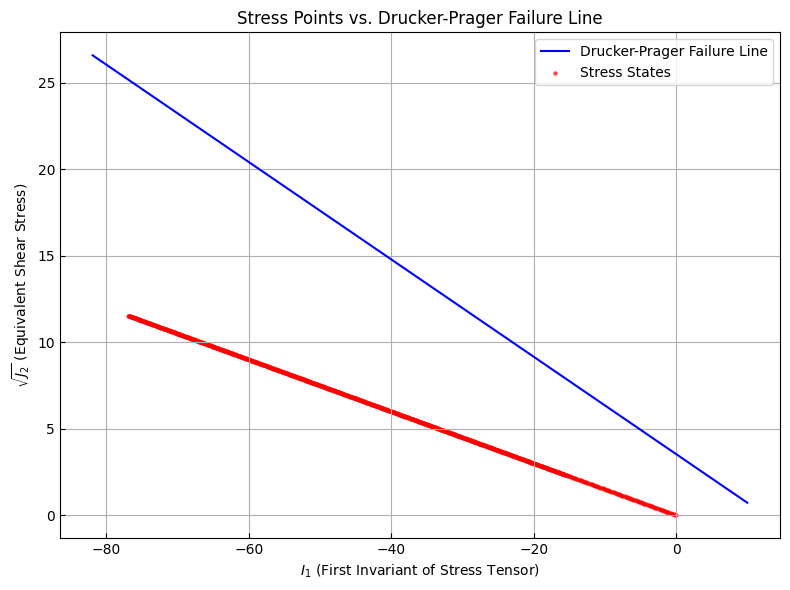

In [536]:
# Step 1: Extract arrays from xarray (shape: [time, GaussPoints])
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1).values  # shape: (1001, 8)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1).values
#sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1).values

# Step 2: Compute I1 = σ11 + σ22 + σ33
I1_vals = sigma11 + sigma22 # First invariant of the stress tensor

# Step 3: Compute deviatoric stress s = σ - (1/3) I1
mean_stress = I1_vals / 2
s11 = sigma11 - mean_stress
s22 = sigma22 - mean_stress
s33 = sigma33 - mean_stress

# Step 4: Compute sqrt(J2) = sqrt(0.5 * (s11² + s22² + s33²))
J2_vals = 0.5 * (s11**2 + s22**2)
sqrt_J2_vals = np.sqrt(J2_vals)

# Step 5: Flatten for scatter plotting
I1_flat = I1_vals.flatten()
sqrt_J2_flat = sqrt_J2_vals.flatten()

# Step 6: Drucker-Prager failure line
rho = 0.398
sigma_Y = 5
I1_line = np.linspace(np.min(I1_flat)-5, np.max(I1_flat)+10, 500)
dp_line = - (1 / np.sqrt(2)) * rho * I1_line + (1 / np.sqrt(2)) * sigma_Y

# Step 7: Plot
plt.figure(figsize=(8, 6))
plt.plot(I1_line, dp_line, label='Drucker-Prager Failure Line', color='blue')
plt.scatter(I1_flat, sqrt_J2_flat, s=5, color='red', alpha=0.6, label='Stress States')

plt.xlabel(r'$I_1$ (First Invariant of Stress Tensor)')
plt.ylabel(r'$\sqrt{J_2}$ (Equivalent Shear Stress)')
plt.title('Stress Points vs. Drucker-Prager Failure Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
